<a href="https://colab.research.google.com/github/WellingtonTorres/repo-geral-cd/blob/main/Estrutura-de-Dados-A1053/Atividades/Atividade-06-Despesas/atividade06-despesas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade 06 - Análise de Despesas com Pandas**
# Fatec Deputado Ary Fossen - Jundiaí

Aluno: Wellington Junior Torres de Melo
---

# **Atividade para entrega**

Desenvolver um script em Python utilizando as bibliotecas **Pandas** e **Matplotlib** para:

1. Ler o arquivo `despesas.csv`.
2. Exibir as 5 primeiras linhas do DataFrame.
3. Mostrar informações sobre os tipos.
4. Converter a coluna `mes` para o tipo categórico (ordem de janeiro a junho).
5. Calcular o total de despesas por mês.
6. Calcular o total de despesas por tipo de despesa.
7. Gerar gráfico de barras com o total de despesas por mês.
8. Gerar gráfico de barras com o total de despesas por categoria.
9. Escrever uma análise curta dos resultados obtidos.

---

5 primeiras linhas do DataFrame:
    ano        mes      despesa  valor_despesa
0  2024    janeiro  alimentação          240.0
1  2024    janeiro   transporte          130.0
2  2024  fevereiro  alimentação          250.0
3  2024  fevereiro   transporte          140.0
4  2024      março  alimentação          230.0

Informações do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ano            12 non-null     int64  
 1   mes            12 non-null     str    
 2   despesa        12 non-null     str    
 3   valor_despesa  12 non-null     float64
dtypes: float64(1), int64(1), str(2)
memory usage: 516.0 bytes

Tipos após conversão da coluna "mes" para categórica:
ano                 int64
mes              category
despesa               str
valor_despesa     float64
dtype: object

Total de despesas por mês:
mes
janeiro      370.0
fevereiro    390

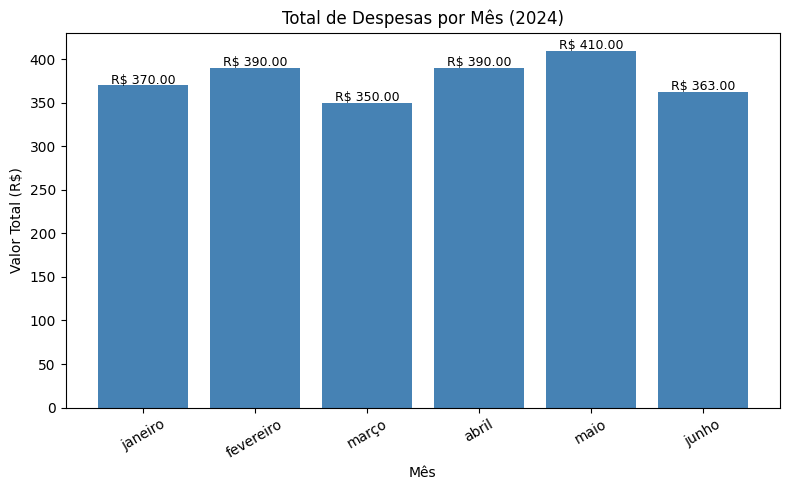

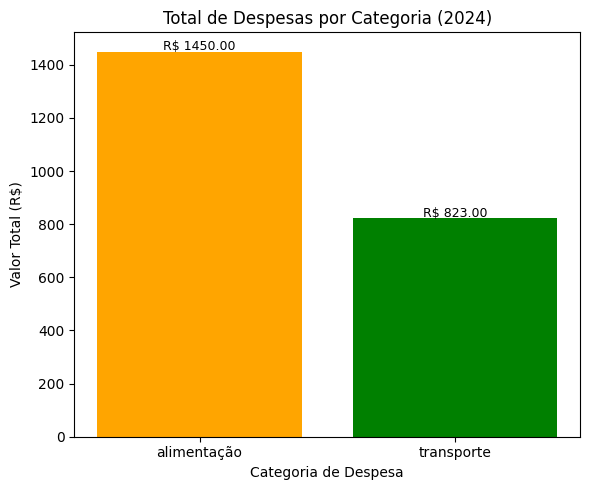

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## 1º etapa: Leitura do arquivo CSV
df = pd.read_csv('despesas.csv')

## 2º Exiba as 5 primeiras linhas do DataFrame
print('5 primeiras linhas do DataFrame:')
print(df.head())
print()

## 3º Mostre informações sobre tipos
print('Informações do DataFrame:')
df.info()
print()

## 4º Converta a coluna mes para o tipo categórico e defina a ordem correta dos meses de janeiro a junho
ordem_meses = ['janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho']
df['mes'] = pd.Categorical(df['mes'], categories=ordem_meses, ordered=True)
print('Tipos após conversão da coluna "mes" para categórica:')
print(df.dtypes)
print()

## 5º Calcule o total de despesas por mês (agrupando por mes e somando valor_despesa)
total_por_mes = df.groupby('mes', observed=True)['valor_despesa'].sum()
print('Total de despesas por mês:')
print(total_por_mes)
print()

## 6º Calcule o total de despesas por tipo de despesa (agrupando por despesa e somando valor_despesa)
total_por_categoria = df.groupby('despesa', observed=True)['valor_despesa'].sum()
print('Total de despesas por categoria:')
print(total_por_categoria)
print()

## 7º Gere um gráfico de barras com Matplotlib mostrando o total de despesas por mês, incluindo título, rótulos nos eixos, e rótulos de mês legíveis.
plt.figure(figsize=(8, 5))
plt.bar(total_por_mes.index.astype(str), total_por_mes.values, color='steelblue')
plt.title('Total de Despesas por Mês (2024)')
plt.xlabel('Mês')
plt.ylabel('Valor Total (R$)')
plt.xticks(rotation=30)
for i, v in enumerate(total_por_mes.values):
    plt.text(i, v + 2, f'R$ {v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('grafico_despesas_por_mes.png')
plt.show()

## 8º Gere um gráfico de barras com o total de despesas por categoria (despesa).
plt.figure(figsize=(6, 5))
plt.bar(total_por_categoria.index, total_por_categoria.values, color=['orange', 'green'])
plt.title('Total de Despesas por Categoria (2024)')
plt.xlabel('Categoria de Despesa')
plt.ylabel('Valor Total (R$)')
for i, v in enumerate(total_por_categoria.values):
    plt.text(i, v + 5, f'R$ {v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('grafico_despesas_por_categoria.png')
plt.show()

## 9º etapa: Análise dos resultados

A partir dos gráficos gerados, é possível observar os seguintes pontos:

- **Meses com maiores gastos:** O mês de **maio** apresentou o maior valor total de despesas (R$ 410,00), seguido por **fevereiro** e **abril** (ambos com R$ 390,00). Os menores totais foram registrados em **março** (R$ 350,00) e **junho** (R$ 363,00).

- **Categorias que mais consomem recursos:** A categoria **alimentação** é a maior responsável pelos gastos no semestre, somando R$ 1.450,00 (cerca de **64%** do total), enquanto **transporte** soma R$ 823,00 (aproximadamente **36%**).

- **Padrões identificados:**
  - Existe certa estabilidade nos gastos mensais, variando entre R$ 350,00 e R$ 410,00.
  - Os gastos com **alimentação** são consistentemente quase o **dobro** dos gastos com **transporte** em todos os meses.
  - Há uma leve tendência de aumento até maio, com queda em junho — possivelmente refletindo ajustes no orçamento doméstico no fim do semestre.

Conclui-se que estratégias de redução de despesas devem priorizar a categoria **alimentação**, por apresentar maior peso no orçamento mensal.